# Module 01 — Sentinel-2 Xarray Pipeline for Bathymetry Estimation

**Workflow overview (with ACOLITE DSF)**

```
GPKG tiles
    └─► per-tile S2 L1C collection (cloud-filtered, dual-mask)
            └─► ACOLITE DSF atmospheric correction (GEE, per-scene)
                    └─► ACOLITE deglinting (per-scene)
                            └─► per-scene Xarray DataArray (xee)
                                    └─► bathymetry estimation (PINN, per scene)
                                            └─► temporal mean bathymetry (per tile)
```



## INSTALLATION AND IMPORT

In [1]:
!pip install -q pystac_client stackstac planetary_computer xarray dask[array]
!pip install -q xee    # Google Earth Engine Xarray backend

# PINN model dependencies
!pip install -q tensorflow scikit-learn rasterio rio-cogeo netcdf4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.3/479.3 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.6 MB/s eta 0:00:00


In [2]:
import sys
ACOLITE_PATH = '/content/drive/MyDrive/Bathymetry/Notebook/acolite-main/acolite-main' # ACOLITE
sys.path.append(ACOLITE_PATH)
import ACOLITE

In [3]:
import os
import ee
import json
import geemap
import sqlite3
import rasterio
import stackstac
import pystac_client
import planetary_computer

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

from rasterio.transform import from_bounds
from rasterio.crs      import CRS
from rio_cogeo.cogeo    import cog_translate
from rio_cogeo.profiles import cog_profiles

from tqdm import tqdm
from datetime import datetime
from pathlib import Path
from pystac_client import Client

import torch
import torch.nn as nn

import sys
sys.path.insert(0, '/content/drive/MyDrive/Bathymetry/Notebook')

from bathymetry_model import (
    load_bathymetry_model,
    BathymetryInference,
    EXPECTED_BANDS
)

from xee.ext import EarthEngineBackendEntrypoint
import xarray.backends.plugins as xr_plugins

xr_plugins.BACKEND_ENTRYPOINTS['ee'] = ('xee.ext', EarthEngineBackendEntrypoint)

import importlib
import sys

# Remove cached module so Python re-reads the file from disk
if 'bathymetry_model' in sys.modules:
    del sys.modules['bathymetry_model']

from bathymetry_model import load_bathymetry_model, BathymetryInference, EXPECTED_BANDS
print('✓ bathymetry_model reloaded')

# Also delete the .pyc cache to be sure
import pathlib
for pyc in pathlib.Path('/content/drive/MyDrive/Bathymetry/Notebook').glob('bathymetry_model*.pyc'):
    pyc.unlink()
for pyc in pathlib.Path('/content/drive/MyDrive/Bathymetry/Notebook/__pycache__').glob('bathymetry_model*.pyc'):
    pyc.unlink()

✓ bathymetry_model reloaded


## INITIALIZE EARTH ENGINE

In [4]:
ee.Authenticate()
ee.Initialize(project='ee-chriscandido93')
print('GEE initialised successfully')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

GEE initialised successfully
Using device: cpu


## LOAD TILES

In [5]:
# =========================
# LOAD GPKG BOUNDING BOXES
# =========================

gpkg_dir = '/content/drive/MyDrive/Bathymetry/GPKG'

bounds_list = []
for file in os.listdir(gpkg_dir):
    if file.endswith('.gpkg'):
        gdf = gpd.read_file(os.path.join(gpkg_dir, file))
        min_lon, min_lat, max_lon, max_lat = gdf.total_bounds
        bounds_list.append({
            'filename': file,
            'min_lon': min_lon, 'min_lat': min_lat,
            'max_lon': max_lon, 'max_lat': max_lat
        })

bounds_df = pd.DataFrame(bounds_list)
print(bounds_df)

                      filename     min_lon    min_lat     max_lon    max_lat
0           Mindanao_tile.gpkg  121.736044   5.351779  126.673972   9.374745
1         NorthLuzon_tile.gpkg  119.506900  14.352658  122.620625  18.775376
2               Sulu_tile.gpkg  118.787441   4.172512  122.789678   7.051896
3            Visayas_tile.gpkg  120.531048   8.836129  126.601240  12.329150
4         SouthLuzon_tile.gpkg  119.328018  11.706214  124.973611  14.706591
5            Palawan_tile.gpkg  115.964644   7.699117  121.547333  12.113016
6     tile_mindoro_target.gpkg  119.995151  13.160611  120.695151  13.960611
7  tile_marinduque_target.gpkg  121.795151  13.160611  122.195151  13.660611
8     tile_palawan_target.gpkg  116.795151   7.360611  117.795151   9.160611


In [6]:
# =========================
# SELECT AREA AND TIME RANGE
# =========================

area = 'tile_palawan_target.gpkg'

row = bounds_df[bounds_df['filename'] == area].iloc[0]
min_lon, min_lat = row['min_lon'], row['min_lat']
max_lon, max_lat = row['max_lon'], row['max_lat']

aoi = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])

start_date = '2025-01-01'
end_date   = '2025-06-30'

print(f'AOI Bounds : ({min_lon:.4f}, {min_lat:.4f}) → ({max_lon:.4f}, {max_lat:.4f})')
print(f'Time Range : {start_date} to {end_date}')

AOI Bounds : (116.7952, 7.3606) → (117.7952, 9.1606)
Time Range : 2025-01-01 to 2025-06-30


In [7]:
# =========================
# TILE LOADING FUNCTION
# =========================

def load_tiles_from_gpkg(gpkg_path):
    """
    Load tiles from the 'grid' table in a GeoPackage SQLite database.

    Returns a list of tile dicts. Each dict contains plain Python scalar
    bounds (left/top/right/bottom) so they can be used with both GEE
    geometries and STAC bounding-box queries.
    """
    conn = sqlite3.connect(gpkg_path)
    cursor = conn.cursor()

    cursor.execute("""
        SELECT fid, id, left, top, right, bottom, row_index, col_index
        FROM grid
        ORDER BY row_index, col_index
    """)
    rows = cursor.fetchall()
    conn.close()

    tiles = []
    for row in rows:
        fid, tid, left, top, right, bottom, row_idx, col_idx = row
        tiles.append({
            'fid'      : fid,
            'id'       : tid,
            'left'     : left,
            'top'      : top,
            'right'    : right,
            'bottom'   : bottom,
            'row_index': row_idx,
            'col_index': col_idx,
            # GEE geometry — used for cloud-filtered collection
            'ee_geom'  : ee.Geometry.Rectangle(
                [left, bottom, right, top],
                proj='EPSG:4326', geodesic=False
            ),
            # Shapely bbox tuple — used for STAC / stackstac
            'bbox'     : (left, bottom, right, top),
        })
    return tiles


gpkg_path = f'/content/drive/MyDrive/Bathymetry/GPKG/{area}'
tiles = load_tiles_from_gpkg(gpkg_path)

print(f'\u2713 Loaded {len(tiles)} tiles')
print('\nFirst 5 tiles:')
for i, t in enumerate(tiles[:5]):
    print(f'  [{i+1}] Tile {t["id"]}: Row {t["row_index"]}, Col {t["col_index"]}'
          f'  Bounds: ({t["left"]:.4f}, {t["bottom"]:.4f}) → ({t["right"]:.4f}, {t["top"]:.4f})')

✓ Loaded 77 tiles

First 5 tiles:
  [1] Tile 2150: Row 121, Col 12  Bounds: (117.5952, 9.0606) → (117.6952, 9.1606)
  [2] Tile 2319: Row 121, Col 13  Bounds: (117.6952, 9.0606) → (117.7952, 9.1606)
  [3] Tile 1982: Row 122, Col 11  Bounds: (117.4952, 8.9606) → (117.5952, 9.0606)
  [4] Tile 2151: Row 122, Col 12  Bounds: (117.5952, 8.9606) → (117.6952, 9.0606)
  [5] Tile 1814: Row 123, Col 10  Bounds: (117.3952, 8.8606) → (117.4952, 8.9606)


## DEFINE FUNCTIONS

In [8]:
# =========================
# ACOLITE PREPROCESSING HELPERS (GEE-side)
# =========================
# select_sentinel2_bands -> to_rrs -> to_10m -> dask_spectrum_fitting -> deglint_alternative

def correct_collection_with_acolite(collection):
    # Step 1: band selection, Rrs conversion, 10m resampling (mappable)
    collection_rrs = (
        collection
        .map(ACOLITE.select_sentinel2_bands)
        .map(ACOLITE.to_rrs)
        .map(ACOLITE.to_10m)
    )

    # DSF + deglint
    collection_list = collection_rrs.toList(collection_rrs.size().getInfo())
    n = collection_list.size().getInfo()

    corrected = []
    for i in range(n):
        img = ee.Image(collection_list.get(i))
        # dask_spectrum_fitting returns (corrected_image, metadata_dict)
        img_dsf = ACOLITE.dask_spectrum_fitting(img)
        # deglint_alternative takes the same (img, meta) as *args
        img_deglint = ACOLITE.deglint_alternative(*img_dsf)
        corrected.append(img_deglint)

    return ee.ImageCollection.fromImages(corrected)


def add_water_quality_products(collection):
    """Add Chl-a and SPM bands to an ACOLITE-corrected collection."""
    collection = collection.map(ACOLITE.add_chl_re_mishra)
    collection = collection.map(ACOLITE.add_spm_nechad2016_665)
    return collection


print('\u2713 ACOLITE preprocessing helpers defined')

✓ ACOLITE preprocessing helpers defined


In [9]:
# =========================
# CLOUD MASKING THRESHOLDS
# =========================

MAX_CLOUD_PROBABILITY = 30
MAX_CLOUD_SCORE_PLUS  = 0.5


def mask_edges(image):
    """Mask scene edges where 20 m / 60 m bands have no data."""
    return image.updateMask(
        image.select('B8A').mask().updateMask(image.select('B9').mask())
    )


def mask_clouds_s2cloudless(image):
    """Mask clouds via s2cloudless probability band (joined as 'cloud_mask')."""
    cloud_prob = ee.Image(image.get('cloud_mask')).select('probability')
    return image.updateMask(cloud_prob.lt(MAX_CLOUD_PROBABILITY))


def mask_clouds_csp(image):
    """Mask clouds via Cloud Score+ cs_cdf band (joined as 'csp_mask')."""
    csp_mask = image.get('csp_mask')
    cs = ee.Algorithms.If(
        ee.Algorithms.IsEqual(csp_mask, None),
        ee.Image.constant(1),
        ee.Image(csp_mask).select('cs_cdf')
    )
    return image.updateMask(ee.Image(cs).gte(MAX_CLOUD_SCORE_PLUS))


def mask_shadows(image):
    """Mask cloud shadows via directional distance transform."""
    nir   = image.select('B8')
    swir1 = image.select('B11')
    blue  = image.select('B2')

    is_dark      = nir.lt(0.12)
    is_not_water = swir1.gt(0.015).Or(blue.divide(nir.add(0.001)).lt(1.5))
    potential_shadow = is_dark.And(is_not_water)

    cloud_mask_img = image.get('cloud_mask')
    cloud_for_proj = ee.Algorithms.If(
        ee.Algorithms.IsEqual(cloud_mask_img, None),
        ee.Image(image.get('csp_mask')).select('cs_cdf').lt(MAX_CLOUD_SCORE_PLUS).unmask(0),
        ee.Image(cloud_mask_img).select('probability').gt(MAX_CLOUD_PROBABILITY)
    )
    cloud_mask = ee.Image(cloud_for_proj)

    shadow_azimuth = ee.Number(90).subtract(
        ee.Number(image.get('MEAN_SOLAR_AZIMUTH_ANGLE'))
    )
    cloud_proj = (
        cloud_mask
        .directionalDistanceTransform(shadow_azimuth, 10)
        .reproject(crs=image.select('B2').projection(), scale=30)
        .select('distance')
        .mask()
    )
    return image.updateMask(potential_shadow.And(cloud_proj).Not())


def mask_clouds_and_quality(image):
    """
    Combined pipeline: s2cloudless → Cloud Score+ → shadow → scale to [0,1].
    """
    masked = mask_clouds_s2cloudless(image)
    masked = mask_clouds_csp(masked)
    masked = mask_shadows(masked)
    return (
        masked
        .divide(10000)
        .copyProperties(image, ['system:time_start', 'CLOUDY_PIXEL_PERCENTAGE'])
    )


def mask_to_extent(image):
    """Clip to AOI extent."""
    mask = ee.Image.constant(1).clip(aoi).mask()
    return image.updateMask(mask)


def mask_to_reef(image):
    """Restrict to Allen Coral Atlas reef pixels."""
    aca = ee.Image('ACA/reef_habitat/v2_0').select('reef_mask')
    return image.updateMask(aca.eq(1)).copyProperties(image, ['system:time_start'])


print('\u2713 Cloud-masking helpers defined')

✓ Cloud-masking helpers defined


In [10]:
# =========================
# GET CLEANED L1C COLLECTION (per tile) — ACOLITE input
# =========================
# Uses COPERNICUS/S2_HARMONIZED (L1C TOA) — ACOLITE DSF requires L1C input.
# Cloud/shadow masking is applied before ACOLITE

# Bands to keep for downstream PINN (after ACOLITE renames to Rrs_*)
BANDS = ['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']  # PINN input bands

# ACOLITE Rrs band name -> PINN band name mapping
ACOLITE_TO_PINN = {
    'Rrs_443': 'B1',
    'Rrs_492': 'B2',
    'Rrs_560': 'B3',
    'Rrs_665': 'B4',
    'Rrs_833': 'B8',
    'Rrs_865': 'B8A',
    'Rrs_1614': 'B11',
    'Rrs_2202': 'B12',
}


def get_cleaned_collection_l1c(tile_geom, start_date, end_date, max_cloud_cover=30):
    criteria = ee.Filter.And(
        ee.Filter.bounds(tile_geom),
        ee.Filter.date(start_date, end_date)
    )

    s2_l1c = (
        ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
        .filter(criteria)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', max_cloud_cover))
        .map(mask_edges)
    )

    # Join 1 — s2cloudless
    s2_clouds = ee.ImageCollection('COPERNICUS/S2_CLOUD_PROBABILITY').filter(criteria)
    s2_joined = ee.ImageCollection(
        ee.Join.saveFirst('cloud_mask').apply(
            primary=s2_l1c, secondary=s2_clouds,
            condition=ee.Filter.equals(leftField='system:index', rightField='system:index')
        )
    ).filter(ee.Filter.notNull(['cloud_mask']))

    # Join 2 — Cloud Score+
    s2_csp = ee.ImageCollection('GOOGLE/CLOUD_SCORE_PLUS/V1/S2_HARMONIZED').filter(criteria)
    s2_dual = ee.ImageCollection(
        ee.Join.saveFirst('csp_mask').apply(
            primary=s2_joined, secondary=s2_csp,
            condition=ee.Filter.equals(leftField='system:index', rightField='system:index')
        )
    )

    # Apply cloud/shadow masks
    cleaned = (
        s2_dual
        .map(mask_clouds_s2cloudless)
        .map(mask_clouds_csp)
        .map(mask_shadows)
        .map(mask_to_extent)
    )
    # Copy time property for downstream joins
    cleaned = cleaned.map(
        lambda img: img.copyProperties(img, ['system:time_start', 'CLOUDY_PIXEL_PERCENTAGE'])
    )

    return cleaned


print('\u2713 get_cleaned_collection_l1c defined')

✓ get_cleaned_collection_l1c defined


In [11]:
def collection_to_xarray(ee_collection, bbox, ee_geom, crs='EPSG:4326', resolution=0.0001):
    n_images = ee_collection.size().getInfo()
    if n_images == 0:
        return None

    ds = xr.open_dataset(
        ee_collection,
        engine='ee',
        crs='EPSG:4326',
        scale=0.0001,
        geometry=ee_geom,
        chunks={'time': -1},
    )

    # Decode time if xee returned int64 ms-since-epoch
    if not np.issubdtype(ds.time.dtype, np.datetime64):
        decoded = pd.to_datetime(ds.time.values, unit='ms', utc=True).tz_localize(None)
        ds = ds.assign_coords(time=decoded)

    # xee with UTM uses uppercase X/Y — rename to lowercase
    da = ds[BANDS].to_array(dim='band')           # (band, time, X, Y)
    da = da.transpose('time', 'band', 'lat', 'lon')   # Y=northing→y, X=easting→x
    da = da.rename({'lat': 'y', 'lon': 'x'})

    return da

## ATMOSPHERIC CORRECTION

ACOLITE DSF provides physically-based atmospheric correction consistent with
the PSeagrasS2 / Roca 2026 methodology.


In [12]:
def process_tile_acolite(tile, start_date, end_date,
                          infer,
                          max_cloud_cover=30,
                          crs='EPSG:4326',
                          resolution=0.0001):
    tile_id = tile['id']
    bbox    = tile['bbox']
    ee_geom = tile['ee_geom']

    # Cloud-masked L1C collection
    l1c_collection = get_cleaned_collection_l1c(
        ee_geom, start_date, end_date, max_cloud_cover
    )

    n_scenes = l1c_collection.size().getInfo()
    if n_scenes == 0:
        print(f'  Tile {tile_id}: no valid L1C scenes — skipping.')
        return None

    print(f'  Tile {tile_id}: {n_scenes} L1C scenes found.')

    # ACOLITE DSF + deglinting (GEE-side)
    print(f'    Applying ACOLITE DSF...')
    l2r_collection = correct_collection_with_acolite(l1c_collection)

    # Clip to reef extent (applied after ACOLITE correction)
    l2r_collection = l2r_collection.map(mask_to_reef)

    # Download to Xarray via xee
    da_lazy = collection_to_xarray(
        l2r_collection, bbox, ee_geom, crs=crs, resolution=resolution
    )
    if da_lazy is None:
        return None

    print(f'    Fetching pixel data...')
    da = da_lazy.compute()

    # Trim coordinate mismatches (xee grid artefact)
    da = da.isel(y=slice(0, len(da.y)), x=slice(0, len(da.x)))
    print(f'    DataArray shape: {da.shape}  bands: {list(da.band.values)}')

    # Remap ACOLITE Rrs band names -> PINN band names
    available = list(da.band.values)
    new_names = [ACOLITE_TO_PINN.get(b, b) for b in available]
    da = da.assign_coords(band=new_names)

    # Select the 8 bands PINN expects; fill missing bands with 0
    pinn_bands = EXPECTED_BANDS  # ['B1','B2','B3','B4','B8','B8A','B11','B12']
    da_pinn_bands = []
    for b in pinn_bands:
        if b in list(da.band.values):
            da_pinn_bands.append(da.sel(band=b))
        else:
            print(f'    ⚠  Band {b} not in ACOLITE output — filling with 0.')
            da_pinn_bands.append(
                xr.zeros_like(da.isel(band=0)).assign_coords(band=b)
            )
    da = xr.concat(da_pinn_bands, dim='band')  # (time, band, y, x)

    # PINN bathymetry per scene
    scene_depth_list = []
    for t in da.time.values:
        scene = da.sel(time=t)  # (band, y, x)
        ny, nx = len(scene.y), len(scene.x)
        scene = xr.DataArray(
            scene.values[:, :ny, :nx],
            dims=['band', 'y', 'x'],
            coords={'band': scene.band, 'y': scene.y, 'x': scene.x},
        )
        valid_count = int(np.isfinite(scene.values).all(axis=0).sum())
        if valid_count == 0:
            print(f'      Scene {t}: all pixels masked — skipping.')
            continue
        depth_da = infer.predict_xarray(scene)      # (y, x)
        depth_da = depth_da.expand_dims(time=[t])   # (1, y, x)
        scene_depth_list.append(depth_da)

    if not scene_depth_list:
        print(f'  Tile {tile_id}: no valid scenes after ACOLITE processing.')
        return None

    scene_depths = xr.concat(scene_depth_list, dim='time')  # (time, y, x)

    # Temporal mean
    mean_depth = scene_depths.mean(dim='time')               # (y, x)

    return {
        'tile_id'     : tile_id,
        'mean_depth'  : mean_depth,
        'scene_depths': scene_depths,
        'n_scenes'    : n_scenes,
    }


print('\u2713 process_tile_acolite defined')

✓ process_tile_acolite defined


In [13]:
# =========================
# LOAD PINN MODEL
# =========================

MODEL_DIR = '/content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4'

# load_bathymetry_model() builds the PINN, restores weights, loads the scaler,
# and returns a ready-to-use BathymetryInference object.
infer = load_bathymetry_model(
    model_dir  = MODEL_DIR,
    depth_min  = 0.0,
    depth_max  = 30.0,
    batch_size = 2048,
    verbose    = True,
)

dummy       = np.random.rand(3, len(EXPECTED_BANDS)).astype('float32')
dummy_depth = infer.predict_array(dummy)
print(f'\nSanity check — 3 dummy depths: {dummy_depth.round(3)} m')

✓ Physics parameters loaded:
    k    = 0.956643
    R0   = 0.812017
    Rinf = 0.113857

Building PINN model skeleton...
✓ Weights restored from: /content/drive/MyDrive/Bathymetry/MODEL/PINN_TRANSFORMER_MODEL_v4/pinn_weights.weights.h5
  k    max_diff = 3.25e-01
  R0   max_diff = 4.04e-01
  Rinf max_diff = 1.49e-08
⚠  No scaler found — inputs must already be normalised.

MODEL READY FOR INFERENCE
  Usage : infer.predict_xarray(scene_da)
       or infer.predict_array(array)  — (n_pixels, 8)
  Bands : ['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']
  Depth : 0.0 – 30.0 m

Sanity check — 3 dummy depths: [1.247 4.117 1.392] m


In [14]:
# =========================
# RUN PIPELINE — with ACOLITE DSF preprocessing
# =========================

TILES_TO_PROCESS = tiles[:5]

results = {}

for i, tile in enumerate(tqdm(TILES_TO_PROCESS, desc='Processing tiles')):
    print(f'\n[Tile {i+1}/{len(TILES_TO_PROCESS)}]  id={tile["id"]}  '
          f'row={tile["row_index"]}  col={tile["col_index"]}')
    try:
        result = process_tile_acolite(
            tile,
            start_date      = start_date,
            end_date        = end_date,
            infer           = infer,
            max_cloud_cover = 30,
            crs             = 'EPSG:32651',
            resolution      = 10,
        )
        if result is not None:
            results[tile['id']] = result
            print(f'    \u2713 Done.  Mean depth: '
                  f'{float(result["mean_depth"].min()):.2f} – '
                  f'{float(result["mean_depth"].max()):.2f} m')
    except Exception as e:
        import traceback
        print(f'    \u2717 Error processing tile {tile["id"]}: {e}')
        traceback.print_exc()

print(f'\n\u2713 Finished.  {len(results)}/{len(TILES_TO_PROCESS)} tiles processed.')

Processing tiles:   0%|          | 0/5 [00:00<?, ?it/s]


[Tile 1/5]  id=2150  row=121  col=12
  Tile 2150: 11 L1C scenes found.
    Applying ACOLITE DSF...
<---------------------------------------------------------------------------------------------------->
Pdark: {'B1': 0.09155135135135138, 'B2': 0.0596, 'B3': 0.037, 'B4': 0.020460000000000002, 'B5': 0.0162, 'B6': 0.0125, 'B7': 0, 'B8': 0.0094, 'B8A': 0, 'B9': 0.0007999999999999995, 'B10': 0.0002999999999999971, 'B11': 0.0037999999999999987, 'B12': 0.0014999999999999998}
Geometry: sza=35.5176875932769, vza=2.9726282726346107, raa=13.093369772389906
Gases: uwv=1.5, uoz=0.3, pressure=1013.25
Lut: sel_lut='ACOLITE-LUT-202110-MOD1', sel_aot=np.float64(0.001)
<---------------------------------------------------------------------------------------------------->
<---------------------------------------------------------------------------------------------------->
Pdark: {'B1': 0.10317499999999999, 'B2': 0.071, 'B3': 0.0435, 'B4': 0.0217, 'B5': 0.015900000000000004, 'B6': 0.0133, 'B7': 0.0064, 'B

/usr/local/lib/python3.12/dist-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


    Fetching pixel data...
    DataArray shape: (11, 8, 1000, 1000)  bands: ['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']


Processing tiles:  20%|██        | 1/5 [16:50<1:07:20, 1010.10s/it]

...

    ✓ Done.  Mean depth: 0.80 – 14.11 m

[Tile 5/5]  id=1814  row=123  col=10
  Tile 1814: 19 L1C scenes found.
    Applying ACOLITE DSF...
<---------------------------------------------------------------------------------------------------->
Pdark: {'B1': 0.08739999999999999, 'B2': 0.0591, 'B3': 0.03595, 'B4': 0.01942857142857143, 'B5': 0.0065, 'B6': 0.0009333333333333333, 'B7': 0, 'B8': 0.005, 'B8A': 0.0010789473684210528, 'B9': 0.001800000000000001, 'B10': 0.00019999999999999987, 'B11': 0.0016, 'B12': 0}
Geometry: sza=34.8224424875336, vza=2.806245644896189, raa=50.24423609899978
Gases: uwv=1.5, uoz=0.3, pressure=1013.25
Lut: sel_lut='ACOLITE-LUT-202110-MOD1', sel_aot=np.float64(0.001)
<---------------------------------------------------------------------------------------------------->
<---------------------------------------------------------------------------------------------------->
Pdark: {'B1': 0.09155135135135138, 'B2': 0.0596, 'B3': 0.037, 'B4': 0.020460000000000002, 'B5': 

/usr/local/lib/python3.12/dist-packages/xee/ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


    Fetching pixel data...
    DataArray shape: (19, 8, 1000, 1000)  bands: ['B1', 'B2', 'B3', 'B4', 'B8', 'B8A', 'B11', 'B12']
      Scene 1970-01-01T00:00:00.001000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.003000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.005000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.006000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.007000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.009000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.011000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.012000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.014000000: all pixels masked — skipping.
      Scene 1970-01-01T00:00:00.016000000: all pixels masked — skipping.


Processing tiles: 100%|██████████| 5/5 [1:11:37<00:00, 859.54s/it]

      Scene 1970-01-01T00:00:00.018000000: all pixels masked — skipping.
    ✓ Done.  Mean depth: 0.80 – 10.78 m

✓ Finished.  5/5 tiles processed.


## VISUALIZATION

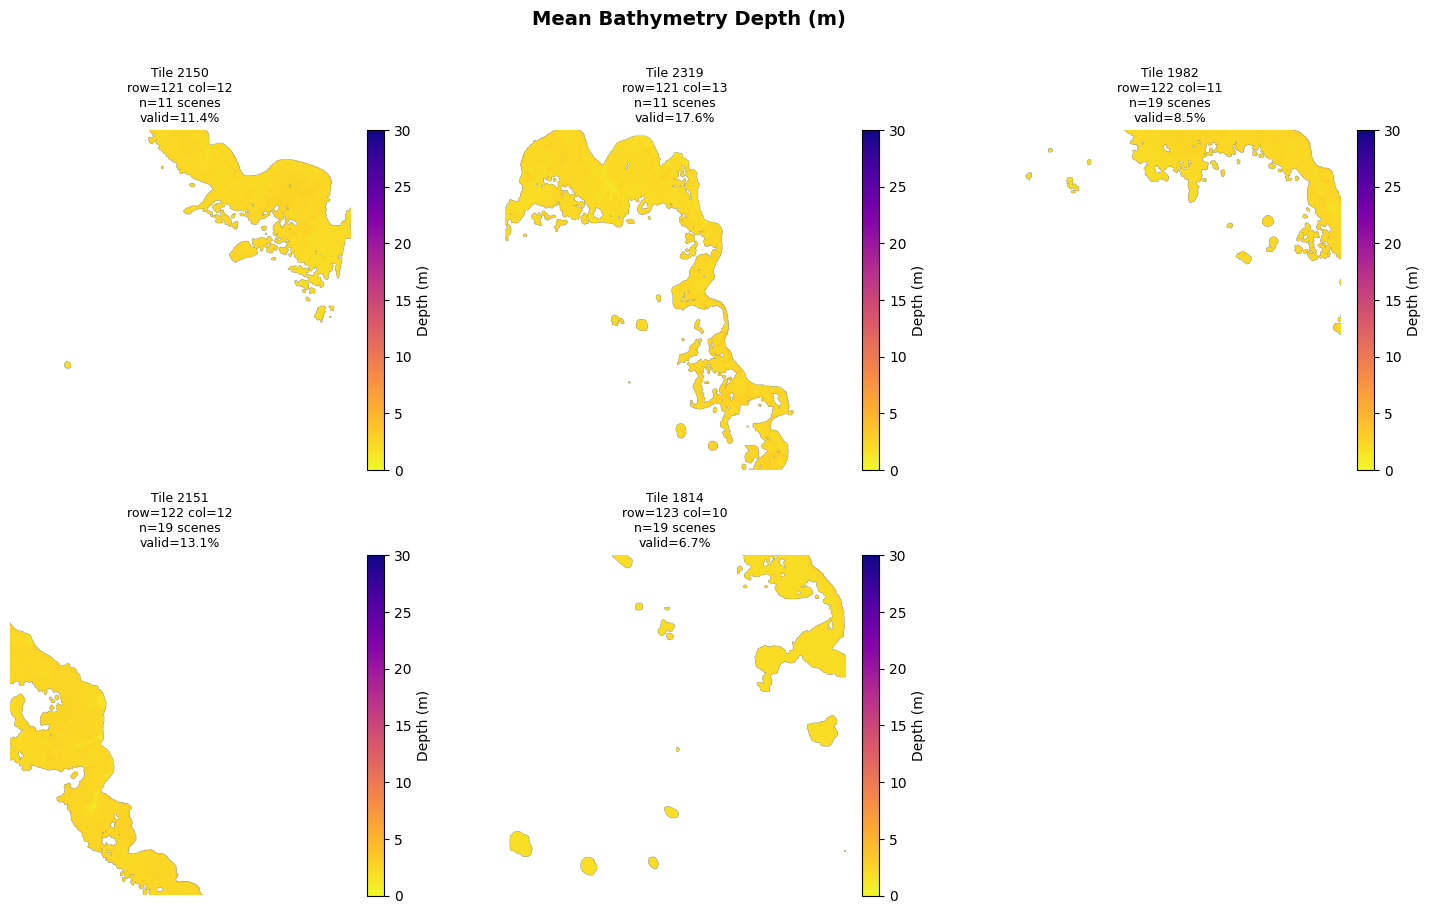

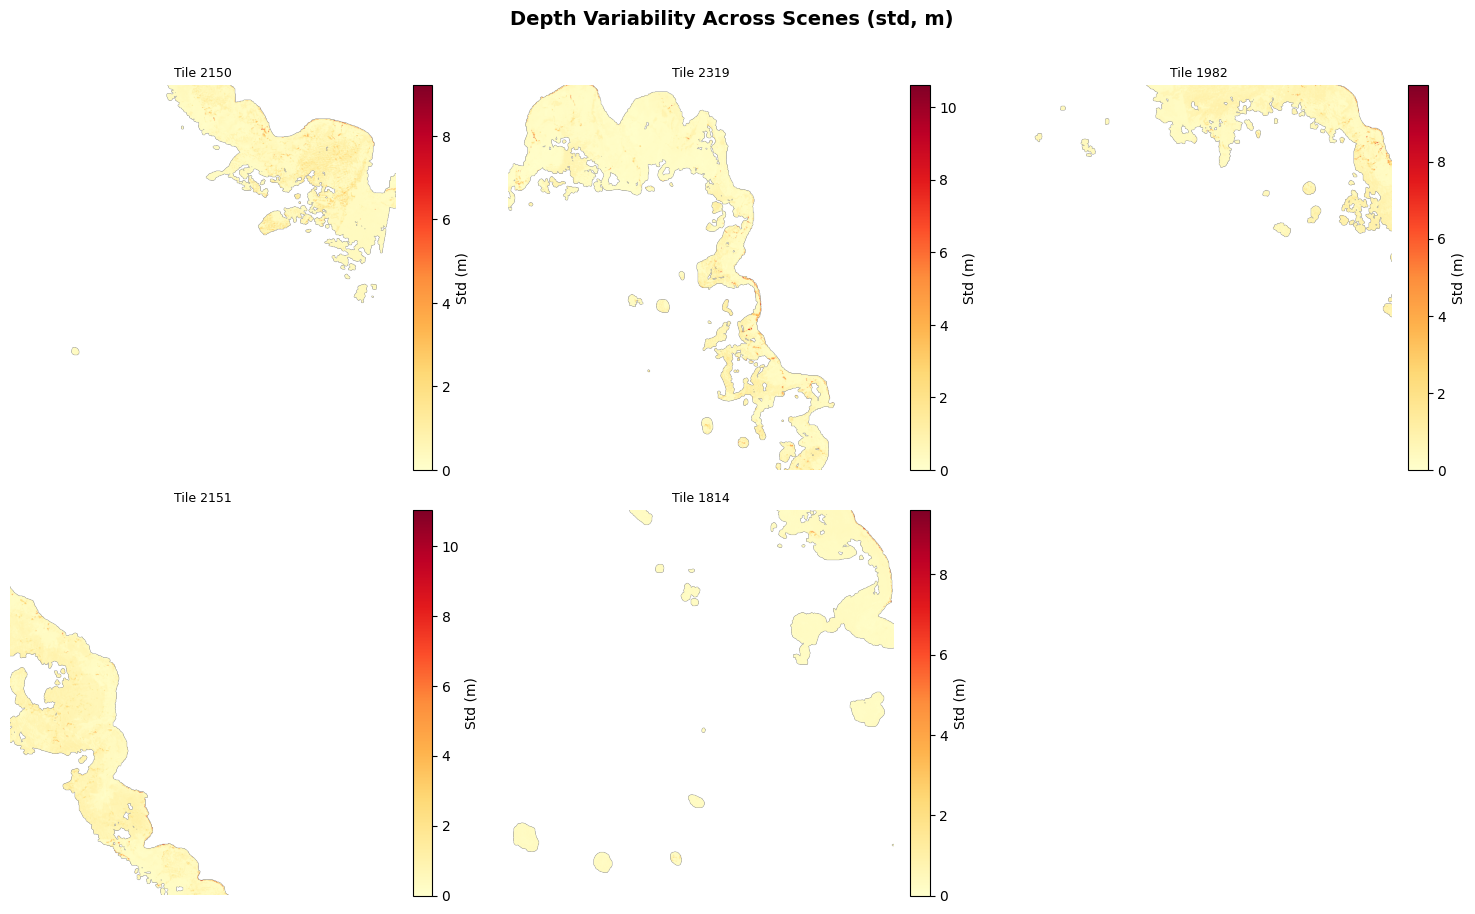

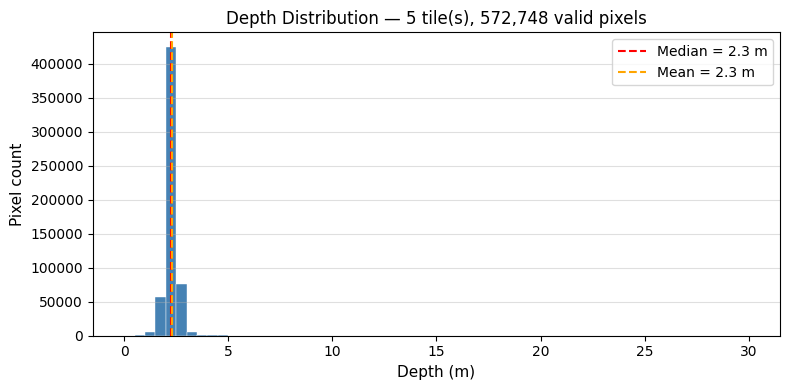


  Tile  Scenes   Valid%   Min(m)  Mean(m)   Max(m)   Std(m)
──────────────────────────────────────────────────────────
  2150      11    11.4%     0.82     2.28    11.50     0.28
  2319      11    17.6%     0.79     2.29    13.29     0.39
  1982      19     8.5%     0.81     2.33    13.35     0.30
  2151      19    13.1%     0.80     2.36    14.11     0.35
  1814      19     6.7%     0.80     2.01    10.78     0.25


In [16]:

import math

def visualize_results(results, tiles_lookup=None, max_cols=3, depth_max=30.0,
                      save_dir=None):
    if not results:
        print('No results to visualize.')
        return

    tile_ids  = list(results.keys())
    n_tiles   = len(tile_ids)
    n_cols    = min(n_tiles, max_cols)
    n_rows    = math.ceil(n_tiles / n_cols)

    cmap_depth = 'plasma_r'   # shallow=bright, deep=dark
    cmap_std   = 'YlOrRd'

    # ── Figure 1: Mean depth maps ─────────────────────────────────────────
    fig1, axes1 = plt.subplots(n_rows, n_cols,
                               figsize=(5 * n_cols, 4.5 * n_rows),
                               squeeze=False)
    fig1.suptitle('Mean Bathymetry Depth (m)', fontsize=14, fontweight='bold', y=1.01)

    for idx, tile_id in enumerate(tile_ids):
        r, c   = divmod(idx, n_cols)
        ax     = axes1[r][c]
        result = results[tile_id]
        depth  = result['mean_depth']

        vals = depth.values
        vmin, vmax = 0.0, depth_max

        im = ax.imshow(
            vals,
            cmap=cmap_depth, vmin=vmin, vmax=vmax,
            origin='upper',
            aspect='equal',
        )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Depth (m)')

        label = f'Tile {tile_id}'
        if tiles_lookup and tile_id in tiles_lookup:
            t = tiles_lookup[tile_id]
            label += f'\nrow={t["row_index"]} col={t["col_index"]}'
        label += f'\nn={result["n_scenes"]} scenes'

        valid_frac = float(np.isfinite(vals).mean())
        label += f'\nvalid={valid_frac:.1%}'

        ax.set_title(label, fontsize=9)
        ax.axis('off')

    # Hide unused axes
    for idx in range(n_tiles, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes1[r][c].set_visible(False)

    fig1.tight_layout()
    if save_dir:
        fig1.savefig(f'{save_dir}/mean_depth.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Temporal std (depth variability across scenes) ─────────
    fig2, axes2 = plt.subplots(n_rows, n_cols,
                               figsize=(5 * n_cols, 4.5 * n_rows),
                               squeeze=False)
    fig2.suptitle('Depth Variability Across Scenes (std, m)',
                  fontsize=14, fontweight='bold', y=1.01)

    for idx, tile_id in enumerate(tile_ids):
        r, c   = divmod(idx, n_cols)
        ax     = axes2[r][c]
        result = results[tile_id]
        std    = result['scene_depths'].std(dim='time')

        im = ax.imshow(
            std.values,
            cmap=cmap_std, vmin=0,
            origin='upper', aspect='equal',
        )
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Std (m)')
        ax.set_title(f'Tile {tile_id}', fontsize=9)
        ax.axis('off')

    for idx in range(n_tiles, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes2[r][c].set_visible(False)

    fig2.tight_layout()
    if save_dir:
        fig2.savefig(f'{save_dir}/depth_variability.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 3: Depth histogram (all tiles combined) ────────────────────
    fig3, ax3 = plt.subplots(figsize=(8, 4))

    all_depths = []
    for tile_id, result in results.items():
        vals = result['mean_depth'].values
        all_depths.append(vals[np.isfinite(vals)].ravel())

    if all_depths:
        combined = np.concatenate(all_depths)
        ax3.hist(combined, bins=60, range=(0, depth_max),
                 color='steelblue', edgecolor='white', linewidth=0.3)
        ax3.axvline(float(np.nanmedian(combined)), color='red',
                    linestyle='--', linewidth=1.5,
                    label=f'Median = {np.nanmedian(combined):.1f} m')
        ax3.axvline(float(np.nanmean(combined)), color='orange',
                    linestyle='--', linewidth=1.5,
                    label=f'Mean = {np.nanmean(combined):.1f} m')
        ax3.set_xlabel('Depth (m)', fontsize=11)
        ax3.set_ylabel('Pixel count', fontsize=11)
        ax3.set_title(f'Depth Distribution — {len(results)} tile(s), '
                      f'{len(combined):,} valid pixels', fontsize=12)
        ax3.legend()
        ax3.grid(axis='y', alpha=0.4)

    fig3.tight_layout()
    if save_dir:
        fig3.savefig(f'{save_dir}/depth_histogram.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────
    print(f'\n{"Tile":>6}  {"Scenes":>6}  {"Valid%":>7}  '
          f'{"Min(m)":>7}  {"Mean(m)":>7}  {"Max(m)":>7}  {"Std(m)":>7}')
    print('─' * 58)
    for tile_id, result in results.items():
        v = result['mean_depth'].values
        v = v[np.isfinite(v)]
        if len(v) == 0:
            print(f'{tile_id:>6}  {result["n_scenes"]:>6}  {"—":>7}  '
                  f'{"—":>7}  {"—":>7}  {"—":>7}  {"—":>7}')
        else:
            valid_pct = 100 * len(v) / result['mean_depth'].size
            print(f'{tile_id:>6}  {result["n_scenes"]:>6}  {valid_pct:>6.1f}%  '
                  f'{v.min():>7.2f}  {v.mean():>7.2f}  {v.max():>7.2f}  {v.std():>7.2f}')


# Build a quick tile_id → tile_dict lookup from the tiles list
tiles_lookup = {t['id']: t for t in tiles}

# Run visualization
visualize_results(results, tiles_lookup=tiles_lookup, depth_max=30.0)

In [19]:
# =========================
# MAP VISUALIZATION
# =========================

!pip install -q plotly ipywidgets

import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, HTML

# ── Inject font ───────────────────────────────────────────────────────────────
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=JetBrains+Mono:wght@300;400;600&display=swap');
.bathy-ctrl { font-family: 'JetBrains Mono', monospace; }
.bathy-ctrl select, .bathy-ctrl button, .bathy-ctrl label {
  background: #161b22 !important; color: #e6edf3 !important;
  border: 1px solid #30363d !important; border-radius: 4px !important;
  font-family: 'JetBrains Mono', monospace !important; font-size: 11px !important;
  padding: 4px 8px !important;
}
.bathy-ctrl label.active {
  background: #00c4b4 !important; color: #0d1117 !important;
  border-color: #00c4b4 !important; font-weight: 600 !important;
}
</style>
"""))


def build_map(results, mode='mean', depth_max=15.0, opacity=0.75,
              mapstyle='carto-darkmatter'):
    traces = []
    all_lats, all_lons = [], []

    # Shared colorscale bounds across all tiles
    if mode == 'std':
        all_std = []
        for res in results.values():
            v = res['scene_depths'].std(dim='time').values
            all_std.append(v[np.isfinite(v)])
        combined_std = np.concatenate(all_std) if all_std else np.array([0, 5])
        vmax = float(np.nanpercentile(combined_std, 95)) if len(combined_std) else 5
        vmin = 0.0
        colorscale = 'YlOrRd'
        cbar_title = 'Depth std (m)'
    else:
        vmin, vmax = 0.0, depth_max
        colorscale = 'Blues_r'
        cbar_title = 'Depth (m)'

    for tile_id, res in results.items():
        if mode == 'mean':
            da = res['mean_depth']
        else:
            da = res['scene_depths'].std(dim='time')

        arr  = da.values
        lats = da.y.values
        lons = da.x.values

        # Downsample large arrays for Colab performance (~150 px per side max)
        max_px = 150
        step_y = max(1, len(lats) // max_px)
        step_x = max(1, len(lons) // max_px)
        arr  = arr [::step_y, ::step_x]
        lats = lats[::step_y]
        lons = lons[::step_x]

        # Flatten + mask NaN
        lon_grid, lat_grid = np.meshgrid(lons, lats)
        flat_lat = lat_grid.ravel()
        flat_lon = lon_grid.ravel()
        flat_val = arr.ravel()

        valid = np.isfinite(flat_val)
        flat_lat = flat_lat[valid]
        flat_lon = flat_lon[valid]
        flat_val = flat_val[valid]

        if len(flat_val) == 0:
            continue

        all_lats.extend(flat_lat.tolist())
        all_lons.extend(flat_lon.tolist())

        # Marker size scales with downsample step so tiles fill consistently
        msize = max(2, min(6, step_y + 1))

        traces.append(go.Scattermapbox(
            lat=flat_lat,
            lon=flat_lon,
            mode='markers',
            marker=dict(
                size=msize,
                color=flat_val,
                colorscale=colorscale,
                cmin=vmin, cmax=vmax,
                opacity=opacity,
                colorbar=dict(
                    title=dict(text=cbar_title, side='right',
                               font=dict(size=10, color='#8b949e')),
                    thickness=12, len=0.55,
                    x=1.01,
                    tickfont=dict(size=9, color='#8b949e'),
                    bgcolor='rgba(13,17,23,0.85)',
                    bordercolor='#30363d', borderwidth=1,
                ),
                showscale=(tile_id == list(results.keys())[0]),
            ),
            text=[
                f"Tile {tile_id}<br>"
                f"lat: {lat:.4f}<br>lon: {lon:.4f}<br>"
                f"{'depth' if mode=='mean' else 'std'}: {v:.2f} m"
                for lat, lon, v in zip(flat_lat, flat_lon, flat_val)
            ],
            hoverinfo='text',
            name=f'Tile {tile_id}',
        ))

    if not all_lats:
        print('No valid pixels to display.')
        return

    center_lat = float(np.mean(all_lats))
    center_lon = float(np.mean(all_lons))

    # Auto zoom based on extent
    lat_span = max(all_lats) - min(all_lats)
    lon_span = max(all_lons) - min(all_lons)
    span = max(lat_span, lon_span)
    zoom = max(7, min(14, round(8.5 - np.log2(span + 0.001))))

    title_text = ('Mean Bathymetry Depth' if mode == 'mean'
                  else 'Depth Variability (std across scenes)')

    fig = go.Figure(traces)
    fig.update_layout(
        mapbox=dict(
            style=mapstyle,
            center=dict(lat=center_lat, lon=center_lon),
            zoom=zoom,
        ),
        paper_bgcolor='#0d1117',
        plot_bgcolor='#0d1117',
        font=dict(family='JetBrains Mono, monospace', color='#e6edf3', size=11),
        title=dict(
            text=title_text,
            font=dict(size=14, color='#00c4b4'),
            x=0.02, y=0.99,
        ),
        margin=dict(l=0, r=0, t=36, b=0),
        height=620,
        legend=dict(
            bgcolor='rgba(13,17,23,0.85)',
            bordercolor='#30363d', borderwidth=1,
            font=dict(size=9, color='#8b949e'),
            x=0.01, y=0.01,
        ),
        showlegend=len(results) > 1,
    )
    return fig


# ── Controls ──────────────────────────────────────────────────────────────────
mode_toggle = widgets.ToggleButtons(
    options=[('Mean depth', 'mean'), ('Variability (std)', 'std')],
    value='mean',
    layout=widgets.Layout(margin='0 16px 0 0'),
)
mode_toggle.add_class('bathy-ctrl')

style_dropdown = widgets.Dropdown(
    options=[
        ('Dark (Carto)',      'carto-darkmatter'),
        ('Light (Carto)',     'carto-positron'),
        ('Street map',        'open-street-map'),
        ('Satellite terrain', 'stamen-terrain'),
    ],
    value='carto-darkmatter',
    description='',
    layout=widgets.Layout(width='160px'),
)
style_dropdown.add_class('bathy-ctrl')

opacity_slider = widgets.FloatSlider(
    value=0.75, min=0.2, max=1.0, step=0.05,
    description='', readout_format='.2f',
    layout=widgets.Layout(width='160px'),
)

depth_slider = widgets.FloatSlider(
    value=15.0, min=0.0, max=60.0, step=5.0,
    description='', readout_format='.0f',
    layout=widgets.Layout(width='160px'),
)

label = lambda txt: widgets.HTML(
    f'<span style="font-family:JetBrains Mono,monospace;font-size:10px;'    f'color:#8b949e;margin:auto 6px;">{txt}</span>'
)

controls = widgets.HBox([
    mode_toggle,
    label('Basemap:'), style_dropdown,
    label('Opacity:'), opacity_slider,
    label('Max depth (m):'), depth_slider,
], layout=widgets.Layout(align_items='center', margin='0 0 8px 0',
                         flex_wrap='wrap'))

out = widgets.Output()

def refresh(change=None):
    with out:
        out.clear_output(wait=True)
        fig = build_map(
            results,
            mode      = mode_toggle.value,
            depth_max = depth_slider.value,
            opacity   = opacity_slider.value,
            mapstyle  = style_dropdown.value,
        )
        if fig:
            fig.show()

for w in [mode_toggle, style_dropdown, opacity_slider, depth_slider]:
    w.observe(refresh, names='value')

refresh()
display(widgets.VBox([controls, out]))


## SAVE RESULTS AS COG FILE

In [ ]:
# =========================
# SAVE RESULTS AS CLOUD-OPTIMIZED GEOTIFF (COG) TO GOOGLE DRIVE
# =========================
SAVE_DIR = '/content/drive/MyDrive/Bathymetry/RESULT/Mindoro'
os.makedirs(SAVE_DIR, exist_ok=True)

TMP_DIR = '/tmp/bathy_cog'
os.makedirs(TMP_DIR, exist_ok=True)

def depth_to_cog(depth_da, out_path, crs_epsg=4326, nodata=np.nan):

    arr = depth_da.values.astype(np.float32)
    arr = np.where(np.isfinite(arr), arr, np.nan)

    y = depth_da.y.values
    x = depth_da.x.values

    res_x = float(x[1] - x[0]) if len(x) > 1 else  0.0001
    res_y = float(y[1] - y[0]) if len(y) > 1 else -0.0001

    # Rasterio requires north-up: y must be descending (res_y < 0)
    # If xee returned ascending lat (south→north), flip the array and y
    if res_y > 0:
        arr = np.flipud(arr)
        y   = y[::-1]
        res_y = -res_y

    # Top-left corner = northwest pixel centre → shift half pixel to edge
    west  = float(x[0])  - res_x / 2
    north = float(y[0])  - res_y / 2   # res_y is negative, so this moves north

    transform = rasterio.transform.from_origin(
        west, north, abs(res_x), abs(res_y)
    )

    tmp_path = os.path.join(TMP_DIR, f'tmp_{os.path.basename(out_path)}')
    os.makedirs(os.path.dirname(tmp_path), exist_ok=True)

    with rasterio.open(
        tmp_path, 'w',
        driver    = 'GTiff',
        height    = arr.shape[0],
        width     = arr.shape[1],
        count     = 1,
        dtype     = 'float32',
        crs       = CRS.from_epsg(crs_epsg),
        transform = transform,
        nodata    = np.nan,
    ) as dst:
        dst.write(arr[np.newaxis, :, :])
        dst.update_tags(BAND_NAME='bathymetry_depth_m')

    cog_profile = cog_profiles.get('deflate')
    cog_profile.update(dtype='float32', nodata=np.nan,
                       blockxsize=512, blockysize=512)

    cog_translate(tmp_path, out_path, cog_profile,
                  overview_resampling='average', quiet=True)
    os.remove(tmp_path)
    return out_path


def save_tile_results_cog(results, save_dir, crs_epsg=32651, depth_max=30.0):
    """
    Save per-tile bathymetry results to Google Drive as COG GeoTIFFs.

    Per tile, saves:
      ├── tile_{id}_mean_depth.tif         — mean depth COG (NaN = masked)
      ├── tile_{id}_scene_depths.tif       — multi-band COG, one band per scene
      ├── tile_{id}_mean_depth.png         — preview colourmap
      └── tile_{id}_summary.json          — depth statistics

    Plus:
      └── all_tiles_summary.json
    """
    summary_all = {}

    for tile_id, result in results.items():
        tile_dir = os.path.join(save_dir, f'tile_{tile_id}')
        os.makedirs(tile_dir, exist_ok=True)

        mean_depth   = result['mean_depth']     # xr.DataArray (y, x)
        scene_depths = result['scene_depths']   # xr.DataArray (time, y, x)
        n_scenes     = result['n_scenes']

        # ── 1. Mean depth COG ─────────────────────────────────────────
        mean_cog_path = os.path.join(tile_dir, f'tile_{tile_id}_mean_depth.tif')
        depth_to_cog(mean_depth, mean_cog_path, crs_epsg=crs_epsg)

        # ── 2. Scene depths COG (multi-band, one band per scene) ──────
        scenes_cog_path = os.path.join(tile_dir, f'tile_{tile_id}_scene_depths.tif')

        arr_scenes = scene_depths.values.astype(np.float32)      # (time, y, x)
        arr_scenes = np.where(np.isfinite(arr_scenes), arr_scenes, np.nan)

        y = scene_depths.y.values
        x = scene_depths.x.values
        res_x = float(x[1] - x[0]) if len(x) > 1 else  0.0001
        res_y = float(y[1] - y[0]) if len(y) > 1 else -0.0001

        if res_y > 0:
            arr_scenes = arr_scenes[:, ::-1, :]   # flip y axis for all time steps
            y          = y[::-1]
            res_y      = -res_y

        west  = float(x[0]) - res_x / 2
        north = float(y[0]) - res_y / 2

        transform = rasterio.transform.from_origin(west, north, abs(res_x), abs(res_y))

        tmp_scenes = os.path.join(TMP_DIR, f'tile_{tile_id}_scene_depths_tmp.tif')
        with rasterio.open(
            tmp_scenes, 'w',
            driver    = 'GTiff',
            height    = arr_scenes.shape[1],
            width     = arr_scenes.shape[2],
            count     = arr_scenes.shape[0],
            dtype     = 'float32',
            crs       = CRS.from_epsg(crs_epsg),
            transform = transform,
            nodata    = np.nan,
        ) as dst:
            for b, t in enumerate(scene_depths.time.values):
                dst.write(arr_scenes[b], b + 1)
                ts = str(np.datetime_as_string(t, unit='D'))
                dst.update_tags(b + 1, DATE=ts)

        cog_profile = cog_profiles.get('deflate')
        cog_profile.update(
            dtype      = 'float32',
            nodata     = np.nan,
            blockxsize = 512,
            blockysize = 512,
        )
        cog_translate(
            tmp_scenes, scenes_cog_path, cog_profile,
            overview_resampling='average', quiet=True,
        )
        os.remove(tmp_scenes)

        # ── 3. PNG preview ────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(6, 5))
        vals    = mean_depth.values
        im      = ax.imshow(
            vals, cmap='plasma_r', vmin=0, vmax=depth_max,
            origin='upper', aspect='equal',
        )
        plt.colorbar(im, ax=ax, label='Depth (m)')
        valid = vals[np.isfinite(vals)]
        title = (
            f'Tile {tile_id}  |  n={n_scenes} scenes\n'
            f'mean={valid.mean():.2f}m  min={valid.min():.2f}m  '
            f'max={valid.max():.2f}m  valid={100*len(valid)/vals.size:.1f}%'
        ) if len(valid) > 0 else f'Tile {tile_id} — no valid pixels'
        ax.set_title(title, fontsize=9)
        ax.axis('off')
        fig.tight_layout()
        png_path = os.path.join(tile_dir, f'tile_{tile_id}_mean_depth.png')
        fig.savefig(png_path, dpi=150, bbox_inches='tight')
        plt.close(fig)

        # ── 4. JSON summary ───────────────────────────────────────────
        if len(valid) > 0:
            stats = {
                'tile_id'         : int(tile_id),
                'n_scenes'        : int(n_scenes),
                'crs_epsg'        : crs_epsg,
                'n_valid_pixels'  : int(len(valid)),
                'valid_pct'       : float(round(100 * len(valid) / vals.size, 2)),
                'depth_min_m'     : float(round(float(valid.min()),         4)),
                'depth_mean_m'    : float(round(float(valid.mean()),        4)),
                'depth_median_m'  : float(round(float(np.median(valid)),    4)),
                'depth_max_m'     : float(round(float(valid.max()),         4)),
                'depth_std_m'     : float(round(float(valid.std()),         4)),
                'files': {
                    'mean_depth_cog'   : mean_cog_path,
                    'scene_depths_cog' : scenes_cog_path,
                    'png'              : png_path,
                },
            }
        else:
            stats = {
                'tile_id'  : int(tile_id),
                'n_scenes' : int(n_scenes),
                'n_valid_pixels': 0,
                'note'     : 'no valid pixels',
            }

        json_path = os.path.join(tile_dir, f'tile_{tile_id}_summary.json')
        with open(json_path, 'w') as f:
            json.dump(stats, f, indent=2)

        summary_all[str(tile_id)] = stats
        print(f'  ✓ Tile {tile_id}  →  {tile_dir}')
        print(f'       mean COG    : {os.path.basename(mean_cog_path)}')
        print(f'       scenes COG  : {os.path.basename(scenes_cog_path)}')

    # ── Combined summary ──────────────────────────────────────────────────
    combined_path = os.path.join(save_dir, 'all_tiles_summary.json')
    with open(combined_path, 'w') as f:
        json.dump(summary_all, f, indent=2)

    print(f'\n✓ All tiles saved  : {save_dir}')
    print(f'✓ Summary JSON     : {combined_path}')
    print(f'✓ Tiles written    : {len(results)}')


save_tile_results_cog(results, save_dir=SAVE_DIR, crs_epsg=4326, depth_max=30.0)